In [46]:
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline
import MATS
from scipy import stats

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")

In [47]:
from MATS.linelistdata import linelistdata
PARAM_LINELIST = linelistdata['O2_ABand_Drouin_2017_linelist']


PARAM_LINELIST['BIA_slope_air'] = 0.0
PARAM_LINELIST.loc[PARAM_LINELIST['m'].notna(), 'BIA_slope_air'] = PARAM_LINELIST[PARAM_LINELIST['m'].notna()]['m'].abs()*-0.01196 + 0.49421



In [48]:
wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-26 #intensities must be above this value for the line to be fit
order_baseline_fit = 1
sample_molefraction = {7 :0.002022}
wave_min = 13150 #cm-1
wave_max = 13165 #cm-1
wave_space = 0.005 #cm-1
baseline_terms = [0] #polynomial baseline coefficients where the index is equal to the coefficient order
PARAM_LINELIST = PARAM_LINELIST[(PARAM_LINELIST['nu']<=wave_max) & (PARAM_LINELIST['nu']>=wave_min)]

spec_1 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = None, baseline_terms = baseline_terms, temperature = 25,  pressure = 1000,
                     wing_cutoff = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': True, 'farwing_continuum': None})




C:\Users\ema3\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ema3\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [63]:
SPECTRA = MATS.Dataset([spec_1], 'Fit_Test',PARAM_LINELIST,  BIA_model = {'sw_depletion': False, 'farwing_continuum': None})  


FITPARAMS = MATS.Generate_FitParam_File(SPECTRA, lineprofile = 'SDNGP', linemixing = True, 
                          fit_intensity = Fit_Intensity, threshold_intensity = IntensityThreshold, sim_window = wave_range,
                          nu_constrain = True, sw_constrain = True, gamma0_constrain = True, delta0_constrain = True, 
                           aw_constrain = True, as_constrain = True, 
                           nuVC_constrain = True, eta_constrain =True, linemixing_constrain = True,
                            additional_columns = ['trans_id', 'local_lower_quanta', 'm'])

FITPARAMS.generate_fit_param_linelist_from_linelist(vary_nu = {7:{1:False, 2:False, 3:False}}, vary_sw = {7:{1:True, 2:False, 3:False}},
                                                    vary_gamma0 = {7:{1: False, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma0 = {7:{1:False}}, 
                                                    vary_delta0 = {7:{1:False , 2:False, 3: False}, 1:{1:False}}, vary_n_delta0 = {7:{1:False}}, 
                                                    vary_aw = {7:{1: False, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma2 = {7:{1:False}}, 
                                                    vary_as = {}, vary_n_delta2 = {7:{1:False}}, 
                                                    vary_nuVC = {7:{1:False, 2:False}}, vary_n_nuVC = {7:{1:False}},
                                                    vary_eta = {}, vary_linemixing = {7:{1:True}})

FITPARAMS.generate_fit_baseline_linelist(vary_baseline = False, vary_molefraction = {7:False, 1:False}, vary_xshift = False, vary_temperature = False, 
                                      vary_etalon_amp= False, vary_etalon_period= False, vary_etalon_phase= False)

,Segment Number,Pressure,Pressure_err,Pressure_vary,Temperature,Temperature_err,Temperature_vary,x_shift,x_shift_err,x_shift_vary,molefraction_O2,molefraction_O2_err,molefraction_O2_vary,baseline_a,baseline_a_err,baseline_a_vary
Spectrum Number,,,,,,,,,,,,,,,,
1,0,1.315789,0.0,False,298.15,0.0,False,0.0,0.0,False,0.002022,0.0,False,0.0,0.0,False


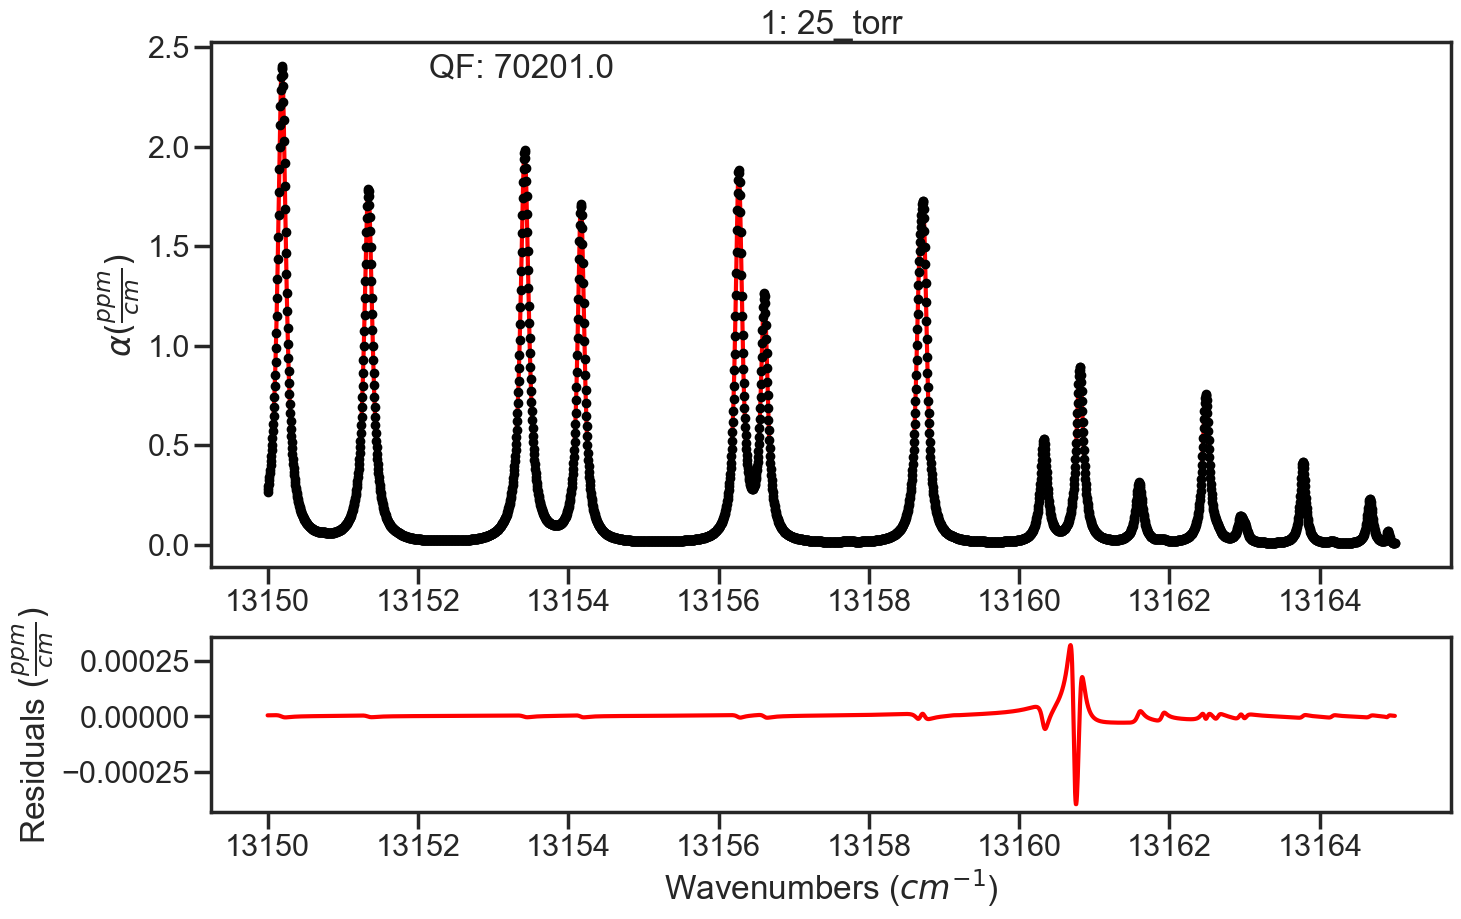

In [64]:
fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', minimum_parameter_fit_intensity = Fit_Intensity/100, weight_spectra = False)


params = fit_data.generate_params()


params = fit_data.constrained_baseline(params, etalon_phase_segment_constrained=False) #etalon_amp_segment_constrained=True, etalon_period_segment_constrained=True, 




result = fit_data.fit_data(params, wing_wavenumbers = 25, wing_method = 'wing_wavenumbers', 
                          method = 'least_squares') #least_squares is TRR and leastsq == LM
fit_data.residual_analysis(result, indv_resid_plot=True)

SPECTRA.generate_summary_file(save_file = True)
fit_data.update_params(result)

In [70]:
fit_parameter_list = pd.read_csv('Parameter_Linelist.csv')

PARAM_LINELIST['sw_fit'] = fit_parameter_list['sw'].values
PARAM_LINELIST['sw_fit_err'] = fit_parameter_list['sw_err'].values
PARAM_LINELIST['y_fit'] = fit_parameter_list['y_air'].values
PARAM_LINELIST['y_fit_err'] = fit_parameter_list['y_air_err'].values

BIA_PARAM_IMPACT= PARAM_LINELIST[['m', 'nu', 'sw', 'y_air', 'sw_fit', 'sw_fit_err', 'y_fit', 'y_fit_err']]

BIA_PARAM_IMPACT['SW BIA PER ERROR'] = 100*(BIA_PARAM_IMPACT['sw_fit']*Fit_Intensity - BIA_PARAM_IMPACT['sw'])/BIA_PARAM_IMPACT['sw']
BIA_PARAM_IMPACT['Y BIA PER ERROR'] = 100*(BIA_PARAM_IMPACT['y_fit'] - BIA_PARAM_IMPACT['y_air'])/BIA_PARAM_IMPACT['y_air']
BIA_PARAM_IMPACT



C:\Users\ema3\AppData\Local\Temp\ipykernel_24392\1276035.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BIA_PARAM_IMPACT['SW BIA PER ERROR'] = 100*(BIA_PARAM_IMPACT['sw_fit']*Fit_Intensity - BIA_PARAM_IMPACT['sw'])/BIA_PARAM_IMPACT['sw']
C:\Users\ema3\AppData\Local\Temp\ipykernel_24392\1276035.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BIA_PARAM_IMPACT['Y BIA PER ERROR'] = 100*(BIA_PARAM_IMPACT['y_fit'] - BIA_PARAM_IMPACT['y_air'])/BIA_PARAM_IMPACT['y_air']


,m,nu,sw,y_air,sw_fit,sw_fit_err,y_fit,y_fit_err,SW BIA PER ERROR,Y BIA PER ERROR
330,32.99404,13150.03270,2.490000e-27,0.000000,0.249000,0.000000,0.000000,0.000000,0.000000e+00,NaN
331,31.98983,13150.05691,9.090000e-29,0.000000,0.009090,0.000000,0.000000,0.000000,1.233266e-14,NaN
332,31.98983,13150.20000,7.700000e-24,-0.000057,766.567039,0.002439,-0.000003,0.000003,-4.458391e-01,-94.689884
333,33.99408,13150.26145,1.230000e-26,0.000000,1.230000,0.000000,0.000000,0.000000,-1.166609e-14,NaN
334,32.99404,13150.48602,3.030000e-27,0.000000,0.303000,0.000000,0.000000,0.000000,0.000000e+00,NaN
...,...,...,...,...,...,...,...,...,...,...
460,32.99404,13164.83151,2.370000e-29,0.000000,0.002370,0.000000,0.000000,0.000000,0.000000e+00,NaN
461,32.99404,13164.85837,1.420000e-28,0.000000,0.014200,0.000000,0.000000,0.000000,-6.947283e-13,NaN
462,31.98983,13164.92000,5.060000e-26,-0.018800,5.053214,0.001196,0.000106,0.000205,-1.341176e-01,-100.565889
463,33.99408,13164.95606,1.990000e-28,0.000000,0.019900,0.000000,0.000000,0.000000,-4.957357e-13,NaN
